Step -1 Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step - 2 Data set Loading

In [3]:
df = pd.read_csv("../data/DisasterDeclarations.csv")

Step 3 — Check Required Columns

In [4]:
df.columns

Index(['femaDeclarationString', 'disasterNumber', 'state', 'declarationType',
       'declarationDate', 'fyDeclared', 'incidentType', 'declarationTitle',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'incidentBeginDate', 'incidentEndDate',
       'disasterCloseoutDate', 'tribalRequest', 'fipsStateCode',
       'fipsCountyCode', 'placeCode', 'designatedArea',
       'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region',
       'designatedIncidentTypes', 'lastRefresh', 'hash', 'id'],
      dtype='object')

Step 4 — Count Disaster Types

In [5]:
incident_counts = df['incidentType'].value_counts()
incident_counts

incidentType
Severe Storm           19299
Hurricane              13721
Flood                  11234
Biological              7857
Fire                    3853
Snowstorm               3707
Severe Ice Storm        2956
Tornado                 1623
Drought                 1292
Winter Storm            1224
Tropical Storm          1059
Coastal Storm            637
Other                    314
Freezing                 301
Earthquake               228
Typhoon                  130
Volcanic Eruption         51
Mud/Landslide             44
Fishing Losses            42
Dam/Levee Break           13
Tsunami                    9
Toxic Substances           9
Chemical                   9
Human Cause                7
Tropical Depression        7
Terrorist                  5
Straight-Line Winds        3
Name: count, dtype: int64

📊 Visualization 1 — Bar Chart

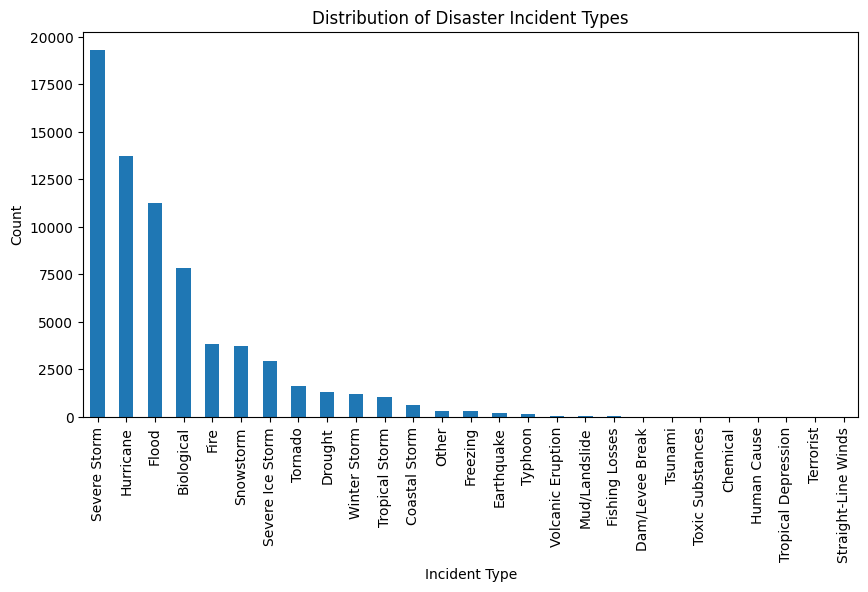

In [6]:
plt.figure(figsize=(10,5))

incident_counts.plot(kind='bar')

plt.title("Distribution of Disaster Incident Types")
plt.xlabel("Incident Type")
plt.ylabel("Count")

plt.show()

✍️ Insight
Identify most frequent disaster type
Compare categories

State vs Incident Type

In [7]:
state_incident = df.groupby(['state','incidentType']).size().unstack().fillna(0)

📊 Visualization 2 — Stacked Bar

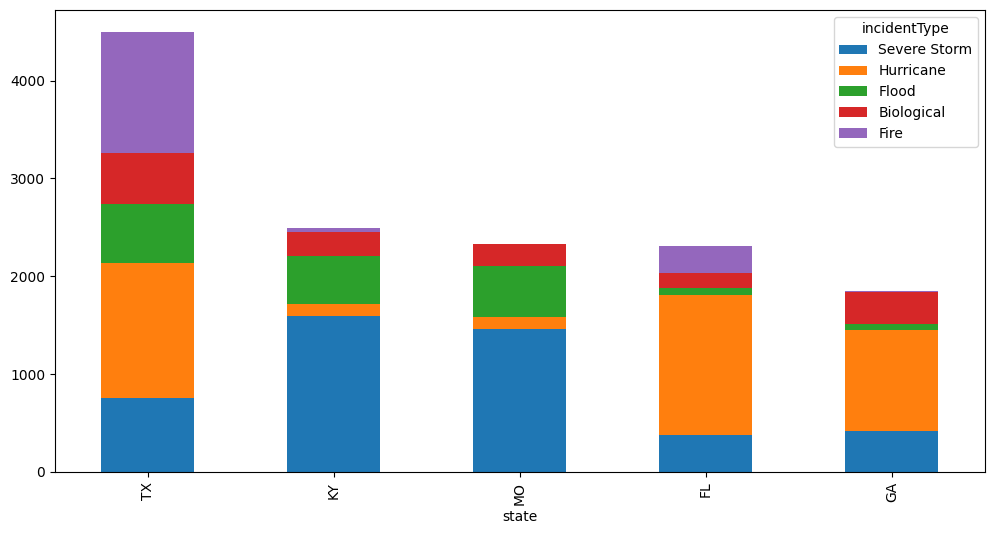

In [10]:
top_states = df['state'].value_counts().head(5).index
top_incidents = df['incidentType'].value_counts().head(5).index

state_incident.loc[top_states, top_incidents].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.show()

📊 Visualization 3 — Heatmap

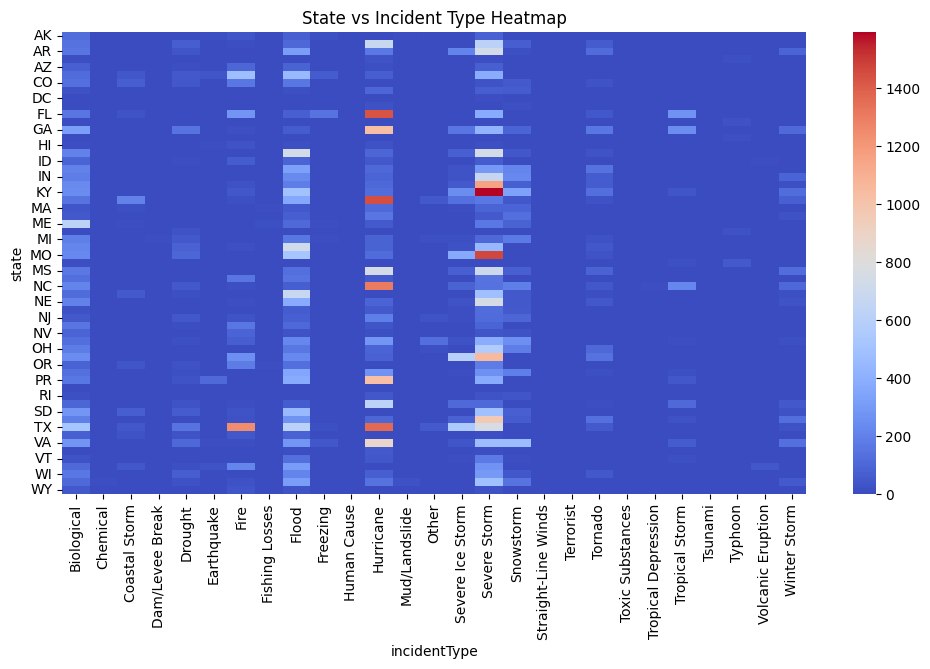

In [11]:
plt.figure(figsize=(12,6))

sns.heatmap(state_incident, cmap='coolwarm')

plt.title("State vs Incident Type Heatmap")

plt.show()

✍️ Insight
Which state has which disaster
Dominant disaster types

Assistance Program Analysis

Step 6 — Group Data

In [12]:
assist_analysis = df.groupby('incidentType')[['ihProgramDeclared','paProgramDeclared']].sum()
assist_analysis

,ihProgramDeclared,paProgramDeclared
incidentType,,
Biological,4115,7673
Chemical,0,9
Coastal Storm,0,614
Dam/Levee Break,5,13
Drought,0,1287
Earthquake,59,184
Fire,184,3666
Fishing Losses,0,0
Flood,795,10464


📊 Visualization 4 — Grouped Bar Chart

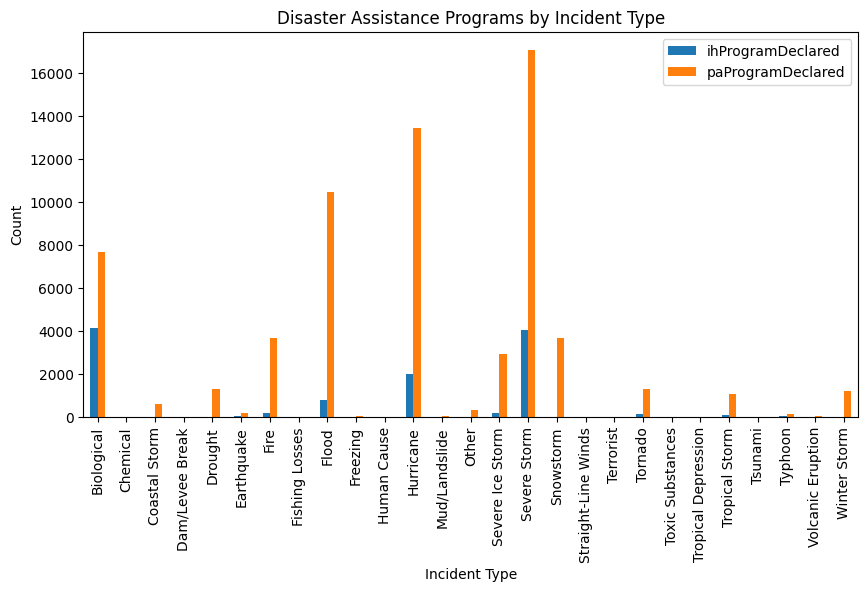

In [13]:
assist_analysis.plot(kind='bar', figsize=(10,5))

plt.title("Disaster Assistance Programs by Incident Type")
plt.xlabel("Incident Type")
plt.ylabel("Count")

plt.show()

✍️ Insight
Which disasters trigger assistance
Compare IH vs PA programs

# Cross-Milestone Insight Synthesis

🔹 Milestone-1 (Data Cleaning & EDA)

The dataset was cleaned by handling missing values and ensuring consistency in key columns such as state and incident type. Data preprocessing ensured that the dataset was reliable and suitable for further analysis.

🔹 Milestone-2 (Temporal Trends)

The temporal analysis revealed that disaster declarations have increased over time. Certain years show higher disaster frequency, indicating growing environmental risks or improved reporting systems.
Seasonal patterns were also observed, with specific months experiencing higher disaster occurrences.

🔹 Milestone-3 (Geographical Patterns)

Geographical analysis showed that disaster occurrences are unevenly distributed across states. Coastal and southern states such as Texas, Florida, and California experience more disasters due to exposure to hurricanes, floods, and wildfires.
Choropleth maps clearly highlighted disaster-prone regions.

🔹 Milestone-4 (Incident Type Analysis)

Incident analysis revealed that certain disaster types such as storms and floods occur more frequently than others. Different states experience different dominant disaster types based on their geographic and climatic conditions.
Assistance programs are more frequently activated for severe disasters.

# Final Combined Insights

The overall analysis of disaster declarations provides a comprehensive understanding of disaster patterns across time, geography, and incident types.

From the temporal perspective, disaster occurrences have shown an increasing trend over the years, with certain months exhibiting seasonal peaks.

Geographical analysis highlights that disaster-prone regions are concentrated in coastal and southern states, where environmental conditions increase vulnerability to natural hazards.

Incident type analysis reveals that storms and floods dominate the dataset, while certain regions experience specific disaster types more frequently.

Additionally, disaster assistance programs are more commonly triggered by high-impact disasters, indicating the severity of such events.

Overall, the integration of temporal, geographical, and incident-based analysis provides valuable insights for disaster management and planning.

# Final Visualization Compilation

🔵 1. Temporal Visualizations (Milestone-2)

In [15]:
df.columns

Index(['femaDeclarationString', 'disasterNumber', 'state', 'declarationType',
       'declarationDate', 'fyDeclared', 'incidentType', 'declarationTitle',
       'ihProgramDeclared', 'iaProgramDeclared', 'paProgramDeclared',
       'hmProgramDeclared', 'incidentBeginDate', 'incidentEndDate',
       'disasterCloseoutDate', 'tribalRequest', 'fipsStateCode',
       'fipsCountyCode', 'placeCode', 'designatedArea',
       'declarationRequestNumber', 'lastIAFilingDate', 'incidentId', 'region',
       'designatedIncidentTypes', 'lastRefresh', 'hash', 'id'],
      dtype='object')

In [16]:
df['declarationDate'] = pd.to_datetime(df['declarationDate'])

In [17]:
df['year'] = df['declarationDate'].dt.year
df['month'] = df['declarationDate'].dt.month

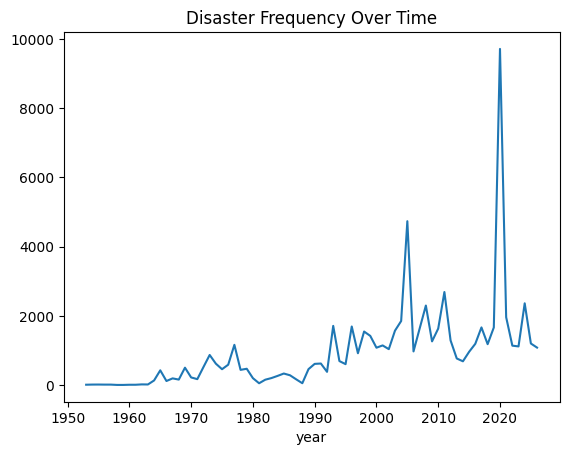

In [18]:
yearly = df.groupby('year').size()

yearly.plot()
plt.title("Disaster Frequency Over Time")
plt.show()

🔵 2. Geographic Visualizations (Milestone-3)

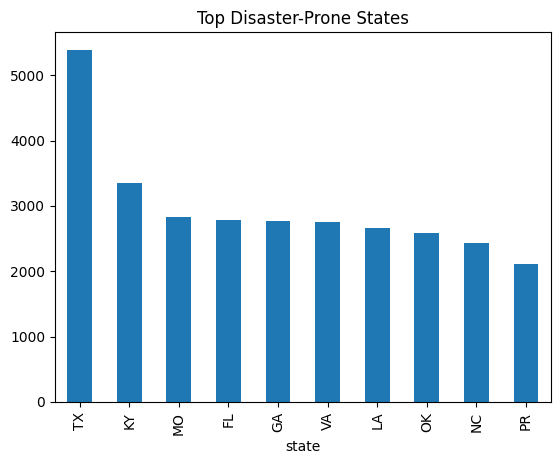

In [19]:
# Top states
df['state'].value_counts().head(10).plot(kind='bar')
plt.title("Top Disaster-Prone States")
plt.show()

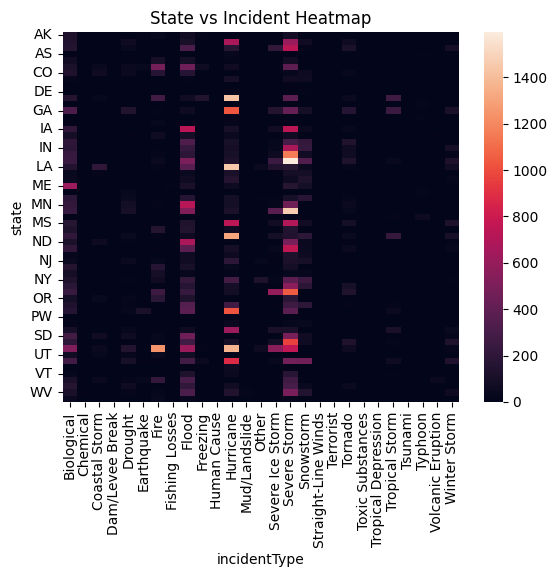

In [20]:
# Heatmap (state vs incident)
sns.heatmap(state_incident)
plt.title("State vs Incident Heatmap")
plt.show()

🔵 3. Incident Analysis (Milestone-4)

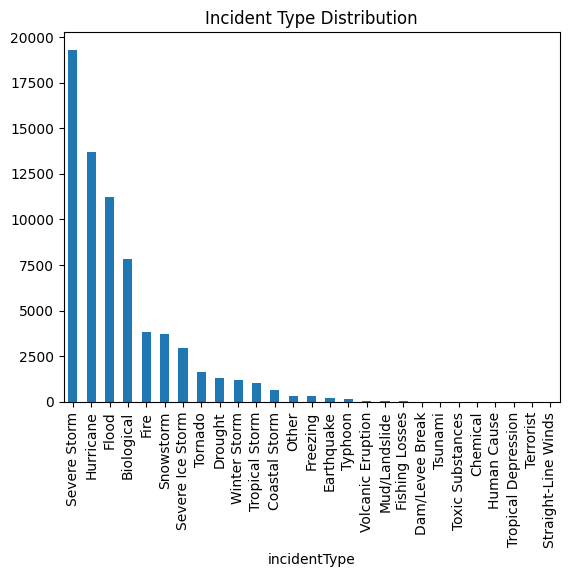

In [21]:
# Incident distribution
df['incidentType'].value_counts().plot(kind='bar')
plt.title("Incident Type Distribution")
plt.show()

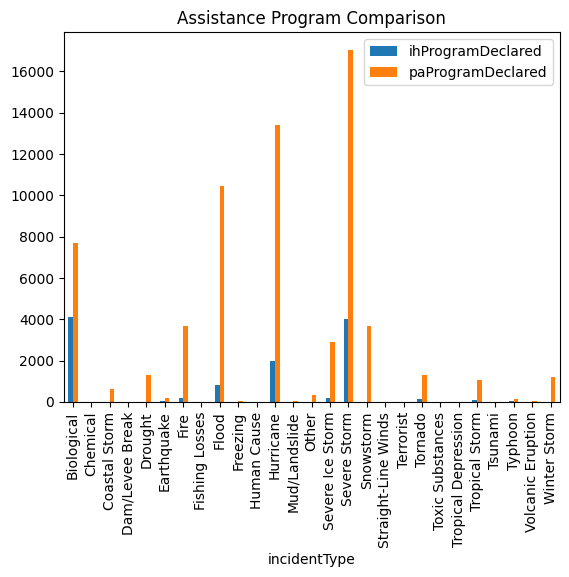

In [22]:
# Assistance programs
assist_analysis.plot(kind='bar')
plt.title("Assistance Program Comparison")
plt.show()

Observation:
The graph shows increasing disaster trends over time.